In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

### Dataset 

In [2]:
raw_df = pd.read_csv("/workspaces/ZoomML_Homeworks/homework_2/car_fuel_efficiency_2026.csv")
len(raw_df)

10000

In [3]:
df = raw_df.copy()[['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']]
df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


### Exploratory Data Analysis (EDA)

Look at the `fuel_efficiency_mpg` variable. Does it have a long tail? 

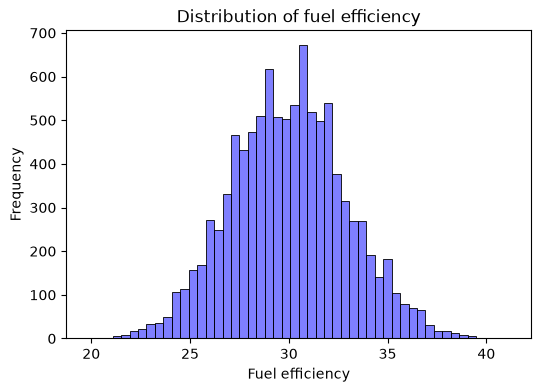

In [4]:
plt.figure(figsize=(6, 4))

sns.histplot(df.fuel_efficiency_mpg, bins=50, color='blue', alpha=0.5)
plt.ylabel('Frequency')
plt.xlabel('Fuel efficiency')
plt.title('Distribution of fuel efficiency')

plt.show()

In [5]:
print("This is not a long-tail distribution.")

This is not a long-tail distribution.


### Question 1: missing values

There's one column with missing values. What is it?

In [6]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [7]:
print("The column with missing values is horsepower.")

The column with missing values is horsepower.


### Question 2: median for horsepower

What's the median (50% percentile) for variable `'horsepower'`?

In [8]:
horsepower = df["horsepower"]
med_horsepower = horsepower.median()
print("The median for variable horsepower is: ", med_horsepower)

The median for variable horsepower is:  254.0


### Prepare and split the dataset

In [9]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

### Question 3: filling NAs

We need to deal with missing values for the column from Question 1. There are two options: fill it with 0 or with the mean of this variable.

Try both options; for each, train a linear regression model without regularization.
- For computing the mean, use the training only.
- Use the validation dataset to evaluate the models and compare the RMSE of each option
- Round the RMSE scores to 3 decimal digits using `round(score, 3)`.

Which option gives better RMSE?

In [10]:
df_train.columns

Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year',
       'fuel_efficiency_mpg'],
      dtype='str')

In [11]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']    

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']

In [12]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])              #creiamo una colonna di 1 con indice 0
    X = np.column_stack([ones, X])          #aggiungiamo la colonna dei bias   

    XTX = X.T.dot(X)                        #Gram matrix 
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)             #Normal equation    
    
    return w[0], w[1:]

In [13]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

1. Fill the empty values with 0

In [14]:
X_train1 = df_train[base].fillna(0).values

In [15]:
w0_1, w_1 = train_linear_regression(X_train1, y_train)

In [16]:
y_pred_train1 = w0_1 + X_train1.dot(w_1)
print('train RMSE with zeros: ', rmse(y_train, y_pred_train1))

train RMSE with zeros:  2.200184683371397


In [17]:
X_val1 = df_val[base].fillna(0).values

In [18]:
y_pred_val1 = w0_1 + X_val1.dot(w_1)
print('val RMSE with zeros: ', rmse(y_val, y_pred_val1))

val RMSE with zeros:  2.205293194751098


<Axes: ylabel='Density'>

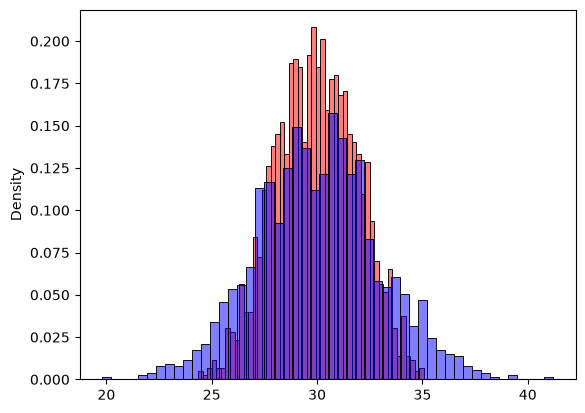

In [19]:
sns.histplot(y_pred_val1, color = 'red', alpha = 0.5, bins = 50, stat = "density")
sns.histplot(y_val, color = 'blue', alpha = 0.5, bins = 50, stat = "density")

2. Fill the empty values with the mean of horsepower values

In [20]:
horsepower_train = df_train["horsepower"]
mean_horsepower_train = horsepower_train.mean()
mean_horsepower_train

np.float64(254.46338337605272)

In [21]:
X_train2 = df_train[base].fillna(mean_horsepower_train).values

In [22]:
w0_2, w_2 = train_linear_regression(X_train2, y_train)

In [23]:
y_pred_train2 = w0_2 + X_train2.dot(w_2)
print('train RMSE with mean: ', rmse(y_train, y_pred_train2))

train RMSE with mean:  2.198101430917093


In [24]:
X_val2 = df_val[base].fillna(mean_horsepower_train).values

In [25]:
y_pred_val2 = w0_2 + X_val2.dot(w_2)
print('val RMSE with mean: ', rmse(y_val, y_pred_val2))

val RMSE with mean:  2.201817484568115


<Axes: ylabel='Density'>

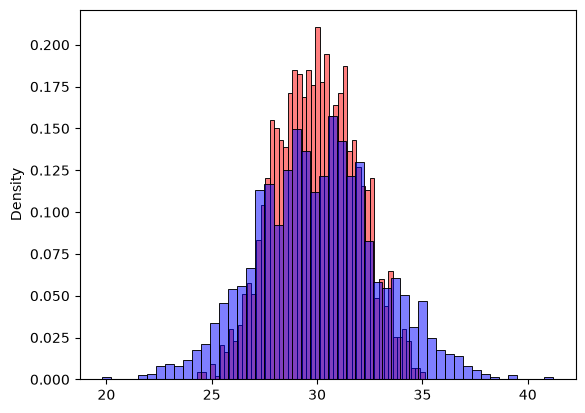

In [26]:
sns.histplot(y_pred_val2, color = 'red', alpha = 0.5, bins = 50, stat = "density")
sns.histplot(y_val, color = 'blue', alpha = 0.5, bins = 50, stat = "density")

In [27]:
print("RMSE with zeros: ", round(rmse(y_val, y_pred_val1), 3))
print("RMSE with mean: ", round(rmse(y_val, y_pred_val2), 3))

RMSE with zeros:  2.205
RMSE with mean:  2.202


### Question 4: best regularization


Now let's train a regularized linear regression (for this question, fill the NAs with 0).
* Try different values of `r` from this list: `[0, 0.01, 0.1, 1, 5, 10, 100]`.
* Use RMSE to evaluate the model on the validation dataset.
* Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.

Which `r` gives the best RMSE? If multiple options give the same best RMSE, select the smallest `r`.

In [28]:
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [29]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train1 = df_train[base].fillna(0).values    
    w0_1, w_1 = train_linear_regression_reg(X_train1, y_train, r = r)

    X_val1 = df_val[base].fillna(0).values
    y_pred_val1 = w0_1 + X_val1.dot(w_1)
    score = rmse(y_val, y_pred_val1)

    print(f"r: {r}, w0: {w0_1}, RMSE: {round(score, 4)}")

r: 0, w0: -153.88496188223104, RMSE: 2.2053
r: 0.01, w0: -148.3092124404723, RMSE: 2.2058
r: 0.1, w0: -111.83871039307081, RMSE: 2.2241
r: 1, w0: -32.331865964969374, RMSE: 2.3492
r: 5, w0: -7.772852209978469, RMSE: 2.4094
r: 10, w0: -3.987116416019025, RMSE: 2.4195
r: 100, w0: -0.4082196488463344, RMSE: 2.4292


In [30]:
print("The best RMSE is given by r = 0")

The best RMSE is given by r = 0


### Question 5: RMSE standard deviation

We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
* Try different seed values: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
* For each seed, do the train/validation/test split with 60%/20%/20% distribution.
* Fill the missing values with 0 and train a model without regularization.
* For each seed, evaluate the model on the validation dataset and collect the RMSE scores. 
* What's the standard deviation of all the scores? To compute the standard deviation, use `np.std`.
* Round the result to 3 decimal digits (`round(std, 3)`)

What's the value of std?

In [31]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

scores = []

for seed in range(10):
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values

    X_train1 = df_train[base].fillna(0).values    
    w0_1, w_1 = train_linear_regression(X_train1, y_train)
    
    X_val1 = df_val[base].fillna(0).values
    y_pred_val1 = w0_1 + X_val1.dot(w_1)
    score = rmse(y_val, y_pred_val1)
    scores.append(score)
    
    print(f"seed: {seed}, w0: {w0_1}, RMSE: {score}")

print(f"std: {round(np.std(scores),3)}")

seed: 0, w0: -150.42885945053604, RMSE: 2.2392041430461465
seed: 1, w0: -151.61231559524666, RMSE: 2.2021128210838907
seed: 2, w0: -152.84068112584038, RMSE: 2.163419778753095
seed: 3, w0: -152.33298096679223, RMSE: 2.2043588768539144
seed: 4, w0: -158.88856816457883, RMSE: 2.2018800943312926
seed: 5, w0: -151.8573533887713, RMSE: 2.2457851509084974
seed: 6, w0: -154.3717913727048, RMSE: 2.269721207952404
seed: 7, w0: -155.0183525899584, RMSE: 2.190794599933433
seed: 8, w0: -150.4381740048234, RMSE: 2.2166112016864443
seed: 9, w0: -154.36007488958072, RMSE: 2.207036592817851
std: 0.029


In [32]:
print("The value of standard deviation is: ", round(np.std(scores),3))

The value of standard deviation is:  0.029


### Question 6: evaluation on test

* Split the dataset like previously, use seed 9.
* Combine train and validation datasets.
* Fill the missing values with 0 and train a model with `r=0.001`. 
* What's the RMSE on the test dataset?

In [33]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [34]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [35]:
df_train_val = pd.concat([df_train, df_val])

y_train_val = np.concatenate([y_train, y_val])

In [36]:
X_train_val = df_train_val[base].fillna(0).values
w0, w = train_linear_regression_reg(X_train_val, y_train_val, r=0.001)

In [ ]:
X_test = df_test[base].fillna(0).values
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
print("test RMSE with zeros: ", round(score, 3))

test RMSE with zeros:  2.236
